# Calibrating WOFOST 8.1 with SNOMIN

This notebook demonstrates gradient-based calibration of the differentiable
WOFOST 8.1 crop growth model with the SNOMIN soil nitrogen model.

We use synthetic `LAI` observations to calibrate two crop parameters,
`TDWI` and `SPAN`. The calibration uses gradients propagated through the
complete crop–soil simulation.

Along the way, we look at how the calibrated parameters affect not only the
calibration target (`LAI`), but also soil nitrogen availability (`NAVAIL`) and
final storage-organ biomass (`TWSO`).

The goal is to illustrate how a differentiable crop growth model can be used
to calibrate parameters by optimizing them directly against observations.


## 1. Setup

The following cell installs the development version of diffWOFOST. The weather
and crop files are included with this notebook. If that folder is not next to
the notebook, the cell fetches it from this repository.


In [ ]:
%pip install --quiet "diffwofost @ git+https://github.com/WUR-AI/diffWOFOST.git" matplotlib


In [ ]:
import urllib.request
from pathlib import Path

# main, once this is merged. The branch remains only until that folder is on main.
REFS = ("main", "wofost81-snomin")
FILES = ("weather_wageningen.xlsx", "crop/winterwheat.yaml", "crop/crops.yaml")


def calibration_data():
    """Use the files shipped with the notebook, or fetch them from this repository."""
    here = Path.cwd().resolve()
    relative = (
        Path("docs/notebooks/snomin_calibration_data"),
        Path("snomin_calibration_data"),
    )
    for base in (here, *here.parents):
        for name in relative:
            candidate = base / name
            if (candidate / "weather_wageningen.xlsx").exists():
                return candidate
    destination = here / "snomin_calibration_data"
    (destination / "crop").mkdir(parents=True, exist_ok=True)
    for ref in REFS:
        base = (
            "https://raw.githubusercontent.com/WUR-AI/diffWOFOST/"
            f"{ref}/docs/notebooks/snomin_calibration_data"
        )
        try:
            for name in FILES:
                urllib.request.urlretrieve(f"{base}/{name}", destination / name)
        except Exception:
            continue
        if (destination / "weather_wageningen.xlsx").exists():
            return destination
    raise FileNotFoundError("snomin_calibration_data is not in this repository")


DATA = calibration_data()
CROP_DIR = DATA / "crop"
WEATHER = DATA / "weather_wageningen.xlsx"
print(f"Weather: {WEATHER.resolve()}")
print(f"Crop file: {(CROP_DIR / 'winterwheat.yaml').resolve()}")


In [ ]:
import datetime as dt
import inspect
import tempfile
import textwrap
from pathlib import Path

import torch
import yaml
from pcse.input import ExcelWeatherDataProvider
from pcse.input import WOFOST81SiteDataProvider_SNOMIN
from pcse.input import YAMLAgroManagementReader
from pcse.input import YAMLCropDataProvider
from pcse.models import Wofost81_NWLP_MLWB_SNOMIN
from pcse.soil.soil_profile import SoilProfile

from diffwofost.physical_models.config import ComputeConfig
from diffwofost.physical_models.config import Configuration
from diffwofost.physical_models.crop.wofost81 import Wofost81
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.parameter_providers import ParameterProvider
from diffwofost.physical_models.soil.soil_wrappers import SoilModuleWrapper_NWLP_MLWB_SNOMIN

ComputeConfig.set_dtype(torch.float64)
ComputeConfig.set_device("cpu")

SOWING = dt.date(2013, 10, 23)
SEASON_END = dt.date(2014, 7, 31)
CROP_NAME = "winterwheat"
VARIETY_NAME = "Arminda"
FERTILIZER_DATES = (SOWING, dt.date(2014, 3, 26), dt.date(2014, 4, 29))


## 2. The model and the experiment

We simulate a winter wheat season from 23 October 2013 to 31 July 2014 using
Wageningen weather data. Three mineral-N applications of $60\ \mathrm{kg\ ha^{-1}}$
are applied at sowing and during stem elongation.

The soil and site configuration follows the SNOMIN example used by PCSE.

We know the parameters used to generate the synthetic observations:
`TDWI` = $593\ \mathrm{kg\ ha^{-1}}$ and `SPAN` = 35 days. We start the
calibration from different values, `TDWI` = $200\ \mathrm{kg\ ha^{-1}}$ and
`SPAN` = 25 days, and test whether gradient-based optimization can recover them.


In [5]:
def example_soil():
    lines = inspect.getdoc(SoilProfile).splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip() == "SoilLayerTypes:")
    end = next(i for i, line in enumerate(lines) if line.strip().startswith("GroundWater:"))
    parsed = yaml.safe_load(textwrap.dedent("\n".join(lines[start : end + 1])))
    profile = parsed["SoilProfileDescription"]
    if "FSOMI" not in profile["SubSoilType"]:
        profile["SubSoilType"]["FSOMI"] = 0.0
    rootable = sum(layer["Thickness"] for layer in profile["SoilLayers"])
    return {"RDMSOL": float(rootable), "SoilProfileDescription": profile}


def weather_rows(start, end):
    provider = ExcelWeatherDataProvider(WEATHER)
    names = (
        "DAY", "LAT", "LON", "ELEV", "IRRAD", "TMIN", "TMAX",
        "VAP", "WIND", "RAIN", "E0", "ES0", "ET0",
    )
    rows = []
    day = start
    while day <= end:
        container = provider(day)
        item = {name: getattr(container, name) for name in names}
        item["TEMP"] = 0.5 * (item["TMIN"] + item["TMAX"])
        item["DTEMP"] = 0.5 * (item["TEMP"] + item["TMAX"])
        rows.append(item)
        day += dt.timedelta(days=1)
    return rows


def agro(start):
    harvest = start + dt.timedelta(days=300)
    dressings = tuple(zip(FERTILIZER_DATES, (60, 60, 60), strict=True))
    events = "\n".join(
        f"""        - {day.isoformat()}:
            amount: {amount}
            application_depth: 10
            cnratio: 0
            initial_age: 0
            f_NH4N: 0.5
            f_NO3N: 0.5
            f_orgmat: 0"""
        for day, amount in dressings
    )
    with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as handle:
        path = Path(handle.name)
        handle.write(
            f"""
AgroManagement:
- {start.isoformat()}:
    CropCalendar:
        crop_name: {CROP_NAME}
        variety_name: {VARIETY_NAME}
        crop_start_date: {start.isoformat()}
        crop_start_type: sowing
        crop_end_date: {harvest.isoformat()}
        crop_end_type: harvest
        max_duration: 300
    TimedEvents:
      - event_signal: apply_n_snomin
        name: Synthetic nitrogen
        comment: amount is kg N/ha because the amendment is entirely mineral
        events_table:
{events}
    StateEvents: null
"""
        )
    try:
        return YAMLAgroManagementReader(str(path))
    finally:
        path.unlink(missing_ok=True)


rows = weather_rows(SOWING, SEASON_END)
crop = YAMLCropDataProvider(Wofost81_NWLP_MLWB_SNOMIN, fpath=CROP_DIR, force_reload=True)
soil = example_soil()
n_layers = len(soil["SoilProfileDescription"]["SoilLayers"])
site = WOFOST81SiteDataProvider_SNOMIN(
    WAV=20.0, CO2=360.0, NH4I=[10.0] * n_layers, NO3I=[1.0] * n_layers
)
campaign = agro(rows[0]["DAY"])
params = ParameterProvider(cropdata=crop, soildata=soil, sitedata=site)
params.set_active_crop(CROP_NAME, VARIETY_NAME, "sowing", "harvest")
true_span = float(params["SPAN"])
true_tdwi = float(params["TDWI"])
print(
    f"Reference SPAN = {true_span:.2f} days, TDWI = {true_tdwi:.1f} kg/ha. "
    f"Simulation = {rows[0]['DAY']} to {rows[-1]['DAY']}."
)


Reference SPAN = 35.00 days, TDWI = 593.0 kg/ha. Simulation = 2013-10-23 to 2014-07-31.


## 3. A first simulation

Before calibrating the model, it is useful to look at one complete simulation.
This gives us a reference for the behaviour we are trying to reproduce and
shows where the nitrogen dynamics enter the simulation.

The first panel shows `LAI`, which will be the variable we use for calibration.
The seasonal pattern captures the emergence and expansion of the canopy,
followed by senescence. These are the observations that the optimization will
try to reproduce.

The second panel shows `NAVAIL`, the mineral nitrogen available to the crop.
Unlike a fixed nitrogen supply, `NAVAIL` changes throughout the season. It
responds to mineralisation and fertilizer inputs, while nitrogen is removed
through crop uptake, leaching and denitrification and redistributed through
processes such as nitrification and immobilisation. The fertilizer applications
are marked on the figure, so their effect on the soil nitrogen dynamics can be
seen directly.

The third panel shows `TWSO`, the dry weight of the storage organs. It
accumulates as the crop grows and provides the simulated grain yield at
harvest. `TWSO` is not used during calibration; we show it to see how fitting
the canopy dynamics affects the final crop outcome.

The simulation below uses the parameter values that generated the synthetic
observations: `TDWI` = $593\ \mathrm{kg\ ha^{-1}}$ and `SPAN` = 35 days.
Later, we will start from different parameter values and use gradients through
this complete simulation to calibrate them from `LAI`.


Reference peak LAI = 4.87. Harvest TWSO = 8832 kg/ha.


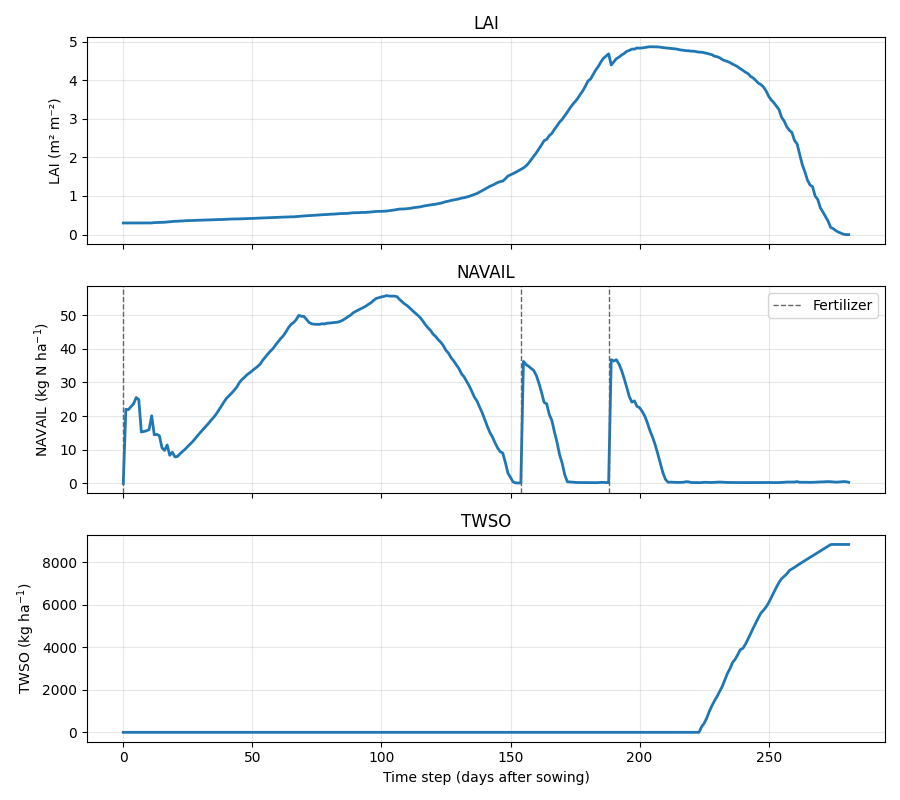

In [5]:
config = Configuration(
    CROP=Wofost81,
    SOIL=SoilModuleWrapper_NWLP_MLWB_SNOMIN,
    OUTPUT_VARS=["LAI", "NAVAIL", "TWSO"],
)


def run(span, tdwi):
    """One SNOMIN season. Either argument may be a tensor that requires a gradient."""
    params.set_override("SPAN", span, check=False)
    params.set_override("TDWI", tdwi, check=False)
    model = Engine(config)
    model.setup(params, iter(rows), campaign)
    model.run_till(rows[-1]["DAY"])
    output = model.get_output()
    return {
        name: torch.stack([day[name].reshape(()) for day in output])
        for name in ("LAI", "NAVAIL", "TWSO")
    }


with torch.no_grad():
    observed = run(
        torch.tensor(true_span, dtype=torch.float64),
        torch.tensor(true_tdwi, dtype=torch.float64),
    )
print(
    f"Reference peak LAI = {observed['LAI'].max().item():.2f}. "
    f"Harvest TWSO = {observed['TWSO'][-1].item():.0f} kg/ha."
)

import matplotlib.pyplot as plt

days = range(len(observed["LAI"]))
fertilizer_days = [(day - SOWING).days for day in FERTILIZER_DATES]
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
panels = (
    ("LAI", "LAI (m² m⁻²)", "LAI"),
    ("NAVAIL", "NAVAIL (kg N ha$^{-1}$)", "NAVAIL"),
    ("TWSO", "TWSO (kg ha$^{-1}$)", "TWSO"),
)
for ax, (key, ylabel, title) in zip(axes, panels, strict=True):
    values = observed[key].detach().numpy()
    ax.plot(days, values, linewidth=2)
    if key == "NAVAIL":
        for index, day in enumerate(fertilizer_days):
            ax.axvline(
                day,
                color="0.4",
                linestyle="--",
                linewidth=1,
                label="Fertilizer" if index == 0 else None,
            )
        ax.legend()
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time step (days after sowing)")
fig.tight_layout()
plt.show()


## 4. What is differentiable?

The calibration uses gradient-based optimization through the PyTorch computation
graph.

1. Treat `TDWI` and `SPAN` as differentiable tensors.
2. Run WOFOST 8.1 with SNOMIN for the whole season.
3. Compute a loss from the simulated and reference `LAI` trajectories.
4. Call `loss.backward()`. PyTorch backpropagates through the simulation and
   computes the gradient of the loss with respect to each parameter.
5. Use these gradients to update the parameters.
6. Repeat.

Most of the model can be differentiated directly using PyTorch operations.
The implementation also handles the threshold-based processes in WOFOST so
that the model can be used for gradient-based calibration while retaining its
original forward behaviour.

The cell below performs one optimization step from the starting values
`SPAN` = 25 days and `TDWI` = $200\ \mathrm{kg\ ha^{-1}}$ and prints the
resulting gradients. The full optimization is shown in the next section.


In [7]:
probe_span = torch.tensor(25.0, dtype=torch.float64, requires_grad=True)
probe_tdwi = torch.tensor(200.0, dtype=torch.float64, requires_grad=True)
probe = run(probe_span, probe_tdwi)
probe_loss = torch.mean(torch.abs(probe["LAI"] - observed["LAI"]))
probe_loss.backward()
print(
    f"Loss {probe_loss.detach().item():.4f}, "
    f"d(loss)/d(SPAN) {probe_span.grad.item():.4e}, "
    f"d(loss)/d(TDWI) {probe_tdwi.grad.item():.4e}"
)


Loss 1.0143, d(loss)/d(SPAN) -6.4281e-03, d(loss)/d(TDWI) -2.2029e-03


## 5. Gradient-based calibration

`LAI` is the calibration target because it provides a time series of canopy
development: when the canopy appears, how large it becomes, and when it
senesces. We therefore fit the model to `LAI`, rather than to yield directly,
and test whether the calibration can recover the parameters that generated the
reference simulation.

The two parameters affect `LAI` in different ways. Increasing `TDWI` increases
early canopy size, whereas increasing `SPAN` prolongs canopy duration. Their
effects can therefore partially compensate, making this a useful example of
parameter interaction.

To keep the parameters within physically plausible ranges, each is represented
by an unbounded logit and mapped to its allowed range using a sigmoid:

* `SPAN`: 10–60 days, starting at 25 days
* `TDWI`: 50–1200 $\mathrm{kg\ ha^{-1}}$, starting at
  $200\ \mathrm{kg\ ha^{-1}}$

The calibration loss is the mean absolute error between the simulated and
reference daily `LAI`.

The optimization trajectory below was generated using 100 Adam steps from
these starting values. It is stored so that the notebook can reproduce the
results without rerunning the full optimization. The next cell plots the
trajectory and runs the model once with the resulting calibrated parameters.

The optional cell afterwards reruns the 100-step optimization from scratch.


In [8]:
# Results from a previously completed 100-step Adam optimization.
precomputed = {
    "step": list(range(100)),
    "loss": [1.0143, 0.9808, 0.9437, 0.9095, 0.8725, 0.8331, 0.7980, 0.7584, 0.7188, 0.6791, 0.6373, 0.5945, 0.5529, 0.5124, 0.4712, 0.4282, 0.3867, 0.3507, 0.3299, 0.3168, 0.3066, 0.2981, 0.2935, 0.2887, 0.2848, 0.2818, 0.2803, 0.2827, 0.2875, 0.2929, 0.2996, 0.3078, 0.3147, 0.3214, 0.3276, 0.3306, 0.3350, 0.3370, 0.3383, 0.3406, 0.3456, 0.3450, 0.3412, 0.3311, 0.3205, 0.3141, 0.3062, 0.3006, 0.2931, 0.2875, 0.2803, 0.2735, 0.2675, 0.2619, 0.2561, 0.2503, 0.2435, 0.2380, 0.2321, 0.2260, 0.2205, 0.2145, 0.2091, 0.2034, 0.1991, 0.1933, 0.1890, 0.1817, 0.1702, 0.1599, 0.1506, 0.1420, 0.1333, 0.1270, 0.1196, 0.1129, 0.1079, 0.0995, 0.0874, 0.0755, 0.0662, 0.0552, 0.0501, 0.0412, 0.0361, 0.0321, 0.0264, 0.0254, 0.0192, 0.0056, 0.0042, 0.0069, 0.0085, 0.0112, 0.0151, 0.0198, 0.0258, 0.0266, 0.0253, 0.0244],
    "SPAN": [25.53, 26.07, 26.62, 27.19, 27.76, 28.34, 28.93, 29.54, 30.15, 30.77, 31.40, 32.05, 32.70, 33.36, 34.02, 34.69, 35.36, 36.04, 36.72, 37.40, 38.07, 38.74, 39.40, 40.04, 40.67, 41.30, 41.89, 42.45, 42.97, 43.43, 43.85, 44.20, 44.51, 44.77, 44.99, 45.17, 45.32, 45.44, 45.53, 45.52, 45.42, 45.25, 45.01, 44.71, 44.42, 44.14, 43.87, 43.60, 43.35, 43.11, 42.87, 42.64, 42.42, 42.21, 42.00, 41.80, 41.60, 41.42, 41.24, 41.06, 40.90, 40.74, 40.58, 40.44, 40.30, 40.16, 39.92, 39.60, 39.30, 39.03, 38.78, 38.55, 38.34, 38.16, 37.99, 37.84, 37.59, 37.25, 36.95, 36.69, 36.45, 36.25, 36.08, 35.93, 35.80, 35.70, 35.62, 35.43, 35.16, 34.94, 34.85, 34.88, 34.82, 34.68, 34.52, 34.36, 34.32, 34.38, 34.43, 34.45],
    "TDWI": [206.6, 213.5, 220.7, 228.1, 235.8, 243.8, 252.1, 260.6, 269.5, 278.7, 288.2, 298.0, 308.2, 318.7, 329.5, 340.7, 352.2, 364.0, 376.1, 388.4, 401.0, 413.8, 426.7, 439.8, 452.9, 466.2, 479.3, 492.1, 504.4, 516.3, 527.5, 538.0, 547.7, 556.8, 565.2, 573.1, 580.5, 587.4, 593.9, 597.6, 599.0, 598.3, 595.8, 591.6, 588.1, 585.0, 582.5, 580.4, 578.8, 577.5, 576.6, 576.0, 575.7, 575.7, 576.0, 576.5, 577.3, 578.3, 579.5, 581.0, 582.6, 584.4, 586.4, 588.6, 590.9, 593.5, 593.6, 591.6, 590.2, 589.3, 589.0, 589.1, 589.7, 590.6, 592.0, 593.7, 593.1, 590.4, 588.6, 587.4, 586.9, 586.9, 587.5, 588.6, 590.2, 592.2, 594.6, 594.7, 592.7, 591.8, 592.9, 595.9, 596.9, 596.2, 594.6, 592.5, 592.6, 594.6, 595.8, 596.3],
}
loss_history = precomputed["loss"]
span_history = precomputed["SPAN"]
tdwi_history = precomputed["TDWI"]
SPAN_INIT, TDWI_INIT = 25.0, 200.0
calibrated_span = 34.45
calibrated_tdwi = 596.3
print(
    f"Stored trajectory: {len(loss_history)} steps. "
    f"Final loss {loss_history[-1]:.4f}, "
    f"SPAN {calibrated_span:.2f}, TDWI {calibrated_tdwi:.1f}."
)


Stored trajectory: 100 steps. Final loss 0.0244, SPAN 34.45, TDWI 596.3.


## Optional: run the full calibration

Set `RUN_CALIBRATION` to `True` to repeat the 100-step search from scratch.
That overwrites the stored trajectory. Leave it `False` to keep the
demonstration on the stored results.

A season takes a few seconds. The trajectory shown below is stored from a
previous 100-step run, so this notebook finishes in seconds. Repeating the
search here takes about fifteen minutes.


In [9]:
# Set to True to reproduce the optimization from scratch.
RUN_CALIBRATION = False

if RUN_CALIBRATION:
    class BoundedParameter(torch.nn.Module):
        def __init__(self, low, high, init_value):
            super().__init__()
            self.low = low
            self.high = high
            init_norm = (init_value - low) / (high - low)
            self.raw = torch.nn.Parameter(
                torch.logit(torch.tensor(init_norm, dtype=torch.float64), eps=1e-6)
            )

        def forward(self):
            return self.low + (self.high - self.low) * torch.sigmoid(self.raw)

    span = BoundedParameter(10.0, 60.0, SPAN_INIT)
    tdwi = BoundedParameter(50.0, 1200.0, TDWI_INIT)
    optimizer = torch.optim.Adam(
        list(span.parameters()) + list(tdwi.parameters()), lr=0.05
    )
    loss_history, span_history, tdwi_history = [], [], []
    for step in range(100):
        optimizer.zero_grad()
        simulated = run(span(), tdwi())
        loss = torch.mean(torch.abs(simulated["LAI"] - observed["LAI"]))
        loss.backward()
        span_gradient = span.raw.grad
        tdwi_gradient = tdwi.raw.grad
        optimizer.step()
        loss_history.append(loss.detach().item())
        span_history.append(span().detach().item())
        tdwi_history.append(tdwi().detach().item())
        print(
            f"Step {step}, loss {loss_history[-1]:.4f}, "
            f"SPAN {span_history[-1]:.2f}, TDWI {tdwi_history[-1]:.1f}, "
            f"grads {span_gradient.item():.4e} {tdwi_gradient.item():.4e}"
        )
    calibrated_span = span_history[-1]
    calibrated_tdwi = tdwi_history[-1]
    print(
        f"Reference SPAN {true_span:.2f}, TDWI {true_tdwi:.1f}. "
        f"Calibrated SPAN {calibrated_span:.2f}, TDWI {calibrated_tdwi:.1f}."
    )
else:
    print(
        "Using the stored 100-step trajectory. "
        f"Calibrated SPAN = {calibrated_span:.2f}, TDWI = {calibrated_tdwi:.1f}."
    )


Using the stored 100-step trajectory. Calibrated SPAN = 34.45, TDWI = 596.3.


## 6. Optimization results

The upper panel is the leaf-area error at each Adam step. The lower panel
shows the two parameters, with dotted lines at the values that generated the
observations. Unless `RUN_CALIBRATION` was set, this is the stored trajectory.


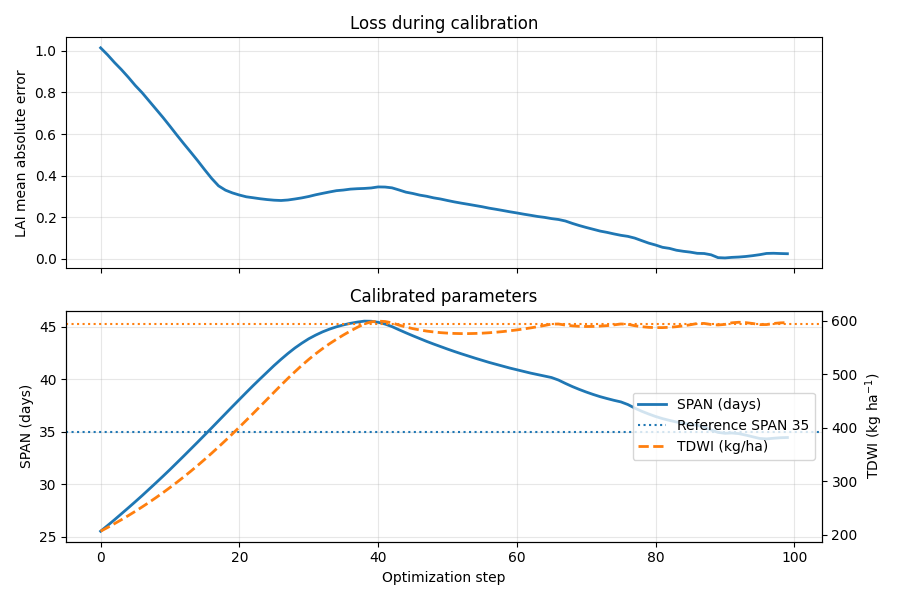

Calibrated: SPAN = 34.45, TDWI = 596.3
Reference:  SPAN = 35.00, TDWI = 593.0


In [8]:
import matplotlib.pyplot as plt

steps = range(len(loss_history))
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(steps, loss_history, linewidth=2)
axes[0].set_ylabel("LAI mean absolute error")
axes[0].set_title("Loss during calibration")
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, span_history, label="SPAN (days)", linewidth=2)
axes[1].axhline(true_span, color="C0", linestyle=":", label=f"Reference SPAN {true_span:.0f}")
tdwi_axis = axes[1].twinx()
tdwi_axis.plot(steps, tdwi_history, color="C1", linestyle="--", label="TDWI (kg/ha)", linewidth=2)
tdwi_axis.axhline(true_tdwi, color="C1", linestyle=":")
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("SPAN (days)")
tdwi_axis.set_ylabel("TDWI (kg ha$^{-1}$)")
axes[1].set_title("Calibrated parameters")
handles, labels = axes[1].get_legend_handles_labels()
tdwi_handles, tdwi_labels = tdwi_axis.get_legend_handles_labels()
axes[1].legend(handles + tdwi_handles, labels + tdwi_labels, loc="center right")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Calibrated: SPAN = {calibrated_span:.2f}, TDWI = {calibrated_tdwi:.1f}")
print(f"Reference:  SPAN = {true_span:.2f}, TDWI = {true_tdwi:.1f}")


## 7. From calibration to the whole system

The calibration uses only `LAI` as its observable, but the calibrated parameters
affect the complete coupled simulation.

`TDWI` and `SPAN` directly affect canopy development. This changes
photosynthesis and nitrogen uptake, which in turn interact with the SNOMIN
nitrogen dynamics. The resulting changes propagate through the crop and soil
system and ultimately affect `TWSO`.

The three figures below show these effects separately:

* **`LAI`** — the variable used for calibration.
* **`NAVAIL`** — the mineral nitrogen available to the crop, showing the
  response of the SNOMIN system and the timing of the three fertilizer
  applications.
* **`TWSO`** — the storage-organ biomass at harvest, showing the resulting
  simulated grain yield.



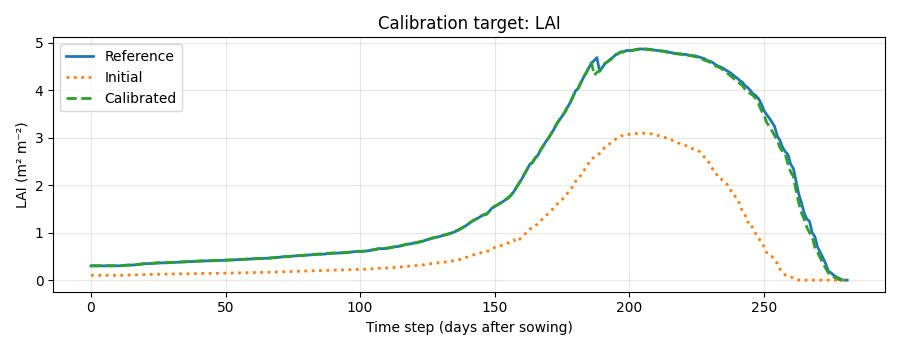

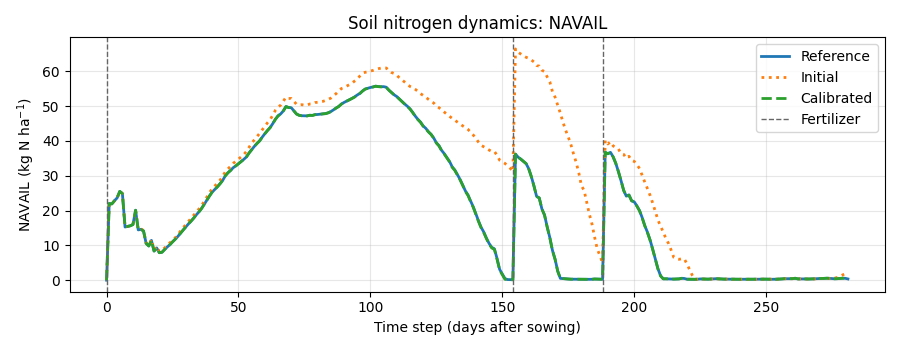

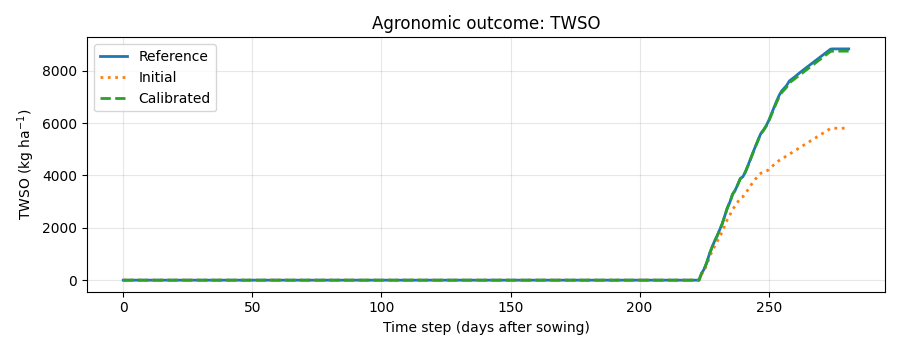

Harvest TWSO: initial 5802, reference 8832, calibrated 8746 kg/ha.


In [10]:
with torch.no_grad():
    initial = run(
        torch.tensor(SPAN_INIT, dtype=torch.float64),
        torch.tensor(TDWI_INIT, dtype=torch.float64),
    )
    optimized = run(
        torch.tensor(calibrated_span, dtype=torch.float64),
        torch.tensor(calibrated_tdwi, dtype=torch.float64),
    )

import matplotlib.pyplot as plt

days = range(len(observed["LAI"]))
fertilizer_days = [(day - SOWING).days for day in FERTILIZER_DATES]
series = (
    ("Reference", observed, "-", 2),
    ("Initial", initial, ":", 2),
    ("Calibrated", optimized, "--", 2),
)


def as_numpy(values):
    return values.detach().numpy() if torch.is_tensor(values) else values


def season_panel(key, ylabel, title):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    for label, trajectory, linestyle, width in series:
        ax.plot(days, as_numpy(trajectory[key]), label=label, linewidth=width, linestyle=linestyle)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time step (days after sowing)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return fig, ax


fig, ax = season_panel("LAI", "LAI (m² m⁻²)", "Calibration target: LAI")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = season_panel(
    "NAVAIL", "NAVAIL (kg N ha$^{-1}$)", "Soil nitrogen dynamics: NAVAIL"
)
for index, day in enumerate(fertilizer_days):
    ax.axvline(
        day,
        color="0.4",
        linestyle="--",
        linewidth=1,
        label="Fertilizer" if index == 0 else None,
    )
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = season_panel("TWSO", "TWSO (kg ha$^{-1}$)", "Agronomic outcome: TWSO")
yields = {
    "Reference": float(as_numpy(observed["TWSO"])[-1]),
    "Initial": float(as_numpy(initial["TWSO"])[-1]),
    "Calibrated": float(as_numpy(optimized["TWSO"])[-1]),
}
ax.legend()
fig.tight_layout()
plt.show()
print(
    f"Harvest TWSO: initial {yields['Initial']:.0f}, "
    f"reference {yields['Reference']:.0f}, "
    f"calibrated {yields['Calibrated']:.0f} kg/ha."
)


## 8. Interpretation

After 100 Adam steps, both parameters are close to the values used to generate
the synthetic observations: `SPAN` = 35 days and `TDWI` =
$593\ \mathrm{kg\ ha^{-1}}$.

The important point is what those parameters do after they have been calibrated.
The loss uses only `LAI`, but `TDWI` and `SPAN` are part of the coupled
crop–soil simulation. The calibrated values therefore also affect nitrogen
uptake and the SNOMIN nitrogen dynamics, as well as biomass accumulation and
final `TWSO`.

The changes in `NAVAIL` around the fertilizer applications illustrate that
SNOMIN is active in the simulation. The agreement in `TWSO` shows that, in
this synthetic experiment, calibrating the canopy dynamics was sufficient to
recover the reference yield.
